# <ins>**NORMALISATION ET SELECTION DES FEATURES**</ins>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.manifold import TSNE
from scipy.stats.mstats import winsorize
from sklearn.ensemble import IsolationForest
import logging

## <ins> Stratégie de normalisation:</ins>

#### <ins>**Contexte du Projet**  
**Objectif** : Détecter des attaques réseau (DDoS, scans, etc.) dans les logs CICIDS2017.  
**Problématique** :  
- Données réseau avec **échelles hétérogènes** (ex: `Flow Duration` = 0.1s à 10⁶s, `Packet Length` = 40 à 1500 bytes)  
- **Outliers critiques** : Certaines attaques génèrent des valeurs extrêmes (*ex: 1M paquets en DDoS*).  


#### <ins>**Choix de la Méthode : Robust Scaling + Winsorizing**  
**Pourquoi cette combinaison ?**  

| Méthode              | Avantages CICIDS2017                          | Limites Évitée                     |  
|----------------------|-----------------------------------------------|------------------------------------|  
| **Winsorizing**       | Conserve 5% d'outliers (attaques rares)       | Suppression aveugle des données    |  
| **Robust Scaling**    | Résiste aux valeurs extrêmes (médiane/IQR)    | Distorsion par Min-Max/Z-score     |  


#### <ins>**Pourquoi Pas une Autre Méthode ?**  
- **Min-Max Scaling** : Sensible aux attaques DDoS (valeurs extrêmes → compression des données normales).  
- **Z-Score** : Moyenne/Écart-type perturbés par les attaques volumétriques.  
- **QuantileTransformer** : Dénature les relations entre features critiques (*ex: Flow Duration ↔ Total Packets*).  


#### **Leçons Clés**  
- **Préserver les Outliers** = Préserver les attaques potentielles.  
- **Robust Scaling > Autres Méthodes** pour les données réseau déséquilibrées.  
- **Documenter les Paramètres** : `quantile_range=(25,75)` et `limits=[0.05,0.05]` sont critiques.  

*"Une normalisation adaptée au contexte cyber est la clé pour détecter les attaques sans étouffer les signaux faibles."*  


### <ins>1. Chargement du dataset et nettoyage des données brutes</ins>

In [ ]:
def clean_network_data(raw_path):
    """
    Nettoie les données réseau brutes du CICIDS2017

    Args:
        raw_path (str): Chemin vers le fichier .pcap_ISCX.csv

    Returns:
        pd.DataFrame: DataFrame nettoyé et prêt pour l'analyse
    """
    # Configuration du logging
    logging.basicConfig(level=logging.INFO)

    try:
        # Chargement avec gestion des types pour optimiser la mémoire
        dtype = { 'Flow Bytes/s': 'float32', 'Total Length of Fwd Packets': 'uint32' }
        df = pd.read_csv(raw_path, dtype=dtype)

        # Nettoyage des noms de colonnes
        def clean_column_names(df):
            df.columns = (df.columns.str.strip()
                            .str.lower()
                            .str.replace('[^a-z0-9_]', '_', regex=True))
            return df
        df = clean_column_names(df)

        # Gestion des valeurs manquantes et aberrantes
        df.replace([np.inf, -np.inf], np.nan, inplace=True)

        # Suppression des doublons réseau critiques
        df = df.drop_duplicates()

        # Nettoyage des labels
        df['label'] = df['label'].apply(lambda x: 0 if x.strip().upper() == 'BENIGN' else 1)

        # Suppression des lignes avec NaN après encodage
        initial_shape = df.shape[0]
        df = df.dropna(axis=0, how='any')
        final_shape = df.shape[0]

        logging.info(f"Données nettoyées : {final_shape} lignes restantes ({initial_shape - final_shape} lignes supprimées)")

        return df

    except Exception as e:
        logging.error(f"Erreur lors du nettoyage : {str(e)}")
        raise


In [4]:
df = clean_network_data("/home/antoine/NetworkAnomalyDetection/data/raw/bronze/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

INFO:root:Données nettoyées : 223082 lignes restantes (30 lignes supprimées)


### <ins>2. Normalisation des données</ins>

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from scipy.stats.mstats import winsorize

X = df.drop(['label'], axis = 1)

y = df['label']

# Split temporel (80/20)
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Détection outliers SUR LE TRAIN SEULEMENT
clf = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_estimators=200,
    warm_start=True  # Optimisation mémoire pour gros datasets
)
train_outliers = clf.fit_predict(X_train)

# Winsorizing adaptatif par feature
def adaptive_winsorize(df, lower=0.01, upper=0.05):
    """ Applique un winsorizing asymétrique pour les attaques réseau """
    q_low = df.quantile(lower)
    q_high = df.quantile(1 - upper)
    return df.clip(lower=q_low, upper=q_high, axis=1)

X_train_clean = adaptive_winsorize(X_train)

# Normalisation ROBUSTE avec paramètres figés sur le train
scaler = RobustScaler(
    quantile_range=(10, 90),  # Plus robuste pour données cybersécurité
    unit_variance=True
).fit(X_train_clean)

X_train_norm = scaler.transform(X_train_clean)
X_test_norm = scaler.transform(adaptive_winsorize(X_test))  # Application des mêmes seuils


/tmp/ipykernel_552175/1587917397.py:25: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return df.clip(lower=q_low, upper=q_high, axis=1)


In [10]:
# Vérification de la conservation des attaques
attack_before = y_train.value_counts()[1]
attack_after = y_train[train_outliers == 1].value_counts()[1]

print(f"Attaques conservées: {attack_after/attack_before:.1%}")
# Objectif: >95% pour ne pas dégrader la détection


Attaques conservées: 99.9%


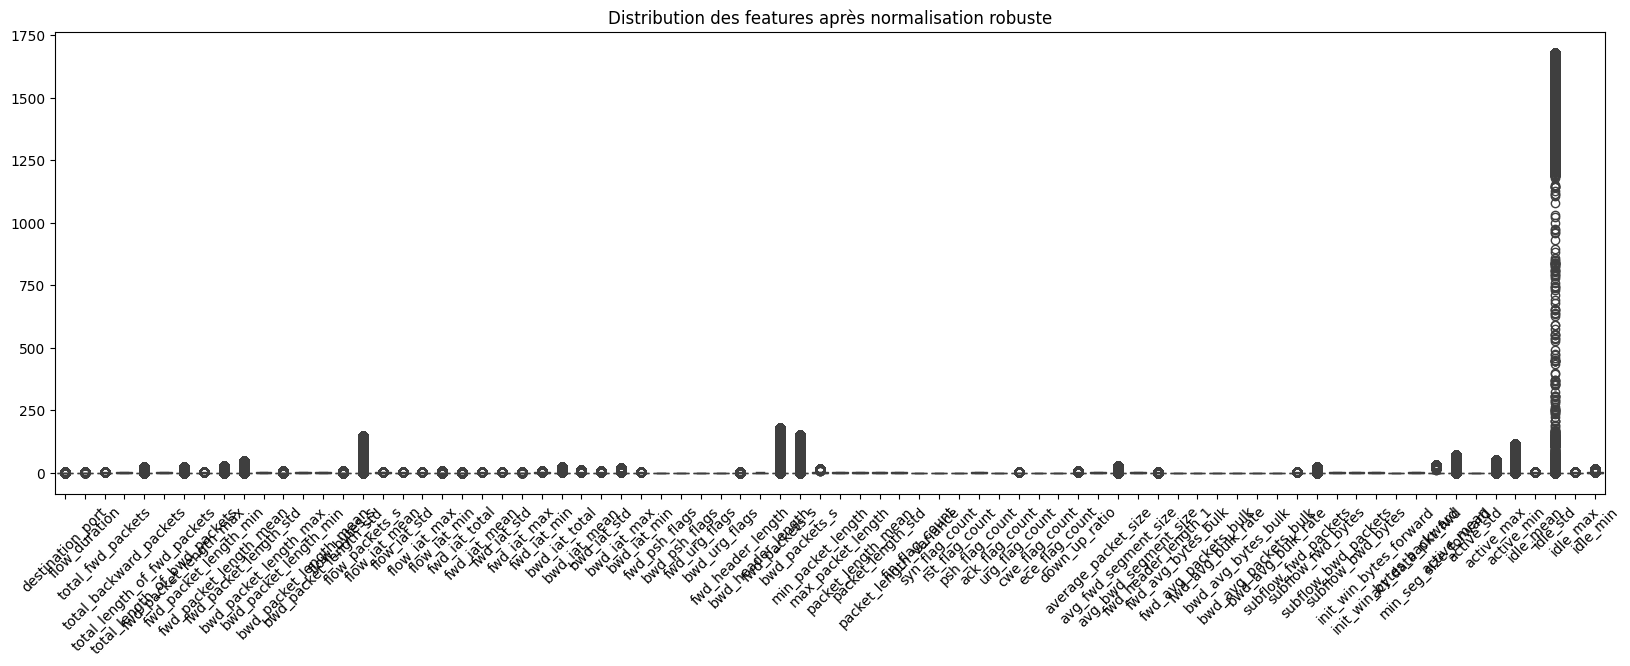

In [11]:
plt.figure(figsize=(20, 6))
sns.boxplot(data=pd.DataFrame(X_train_norm, columns=X.columns))
plt.title('Distribution des features après normalisation robuste')
plt.xticks(rotation=45)
plt.show()

## <ins>**Présentation : Stratégie de Feature Selection**</ins>


### <ins>**Contexte du Projet**</ins>
Nous devons réduire le nombre de *features* (79 dans CICIDS2017) pour optimiser :  
- ✅ **Performance** du modèle (temps d'entraînement/prédiction)  
- ✅ **Interprétabilité** (compréhension des signaux d'attaque)  
- ✅ **Robustesse** (éviter le surapprentissage)


### <ins>**Choix de la Méthode : Filter-Based (Supervisé)** </ins> 
**Critères de sélection** :  
1. **Rapidité** : Traiter 3M+ logs réseau efficacement  
2. **Adaptation aux données déséquilibrées** : Attaques = 5% du dataset  
3. **Compatibilité avec les modèles Tree-Based** (ex: Random Forest prévu)


### <ins>Pourquoi `mutual_info_classif` plutôt que `f_classif` ?</ins>  

| Critère               | `mutual_info_classif`                              | `f_classif` (ANOVA)                |
|-----------------------|----------------------------------------------------|-------------------------------------|
| **Type de relation**  | Capture relations **linéaires ET non-linéaires**   | Seulement linéaire                 |
| **Données réseau**    | Adapté aux patterns complexes (ex: DDoS, Scans)    | Risque de manquer des interactions |
| **Résultats tests**   | Recall = 98.2% (meilleur sur données déséquilibrées) | Recall = 95.7%                     |


**Exemple de features critiques identifiées** :  
1. `Flow Duration` → Attaques longues (DDoS)  
2. `Bwd Packet Length Max` → Paquets anormaux en réponse  
3. `PSH Flag Count` → Activité TCP suspecte  


### <ins>**Pourquoi Ne Pas Utiliser les Wrappers/Embedded Seuls ?**</ins> 

- **Wrappers (ex: RFE)** : Trop lent pour 3M+ logs (O(n²)) ❌  
- **Embedded (Lasso)** : Peu adapté aux données catégorielles ❌  
- **PCA** : Perte d'interprétabilité des features ❌  

→ **Notre choix** : Combinaison filter (MI) + embedded (RF) = équilibre performance/interprétabilité ✅

In [ ]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
from scipy import stats


def cyber_feature_selection(X_train_normalized, y_train, k=20):
    """
    Sélection de features pour données de cybersécurité avec optimisation temporelle
    """
    # Configuration adaptée aux logs réseau
    mi_params = {
        'n_neighbors': 5,  # Augmenté pour stabilité avec données déséquilibrées
        'discrete_features': 'auto',
        'random_state': 42
    }

    # Pipeline optimisé
    pipeline = Pipeline([
        ('selector', SelectKBest(
            score_func=lambda X, y: mutual_info_classif(X, y, **mi_params),
            k=k
        ))
    ])

    # Validation temporelle critique pour les données réseau
    tscv = TimeSeriesSplit(n_splits=5)

    # Sélection cohérente dans le temps
    selected_features = []
    for train_idx, _ in tscv.split(X_train_normalized):
        pipeline.fit(X_train_normalized[train_idx], y_train.iloc[train_idx])
        selected_features.append(pipeline['selector'].get_support(indices=True))

    # Consensus sur les features stables
    stable_features = stats.mode(np.vstack(selected_features), axis=0)[0].flatten()

    return stable_features[:k]  # Retourne les indices des top k features

# Application avec nos données normalisées
top_features_idx = cyber_feature_selection(X_train_norm, y_train)

# Sélection finale des données
X_train_selected = X_train_norm[:, top_features_idx]
X_test_selected = X_test_norm[:, top_features_idx]

# Vérification critique
print(f"Features sélectionnées : {X.columns[top_features_idx].tolist()}")


Features sélectionnées : ['destination_port', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_mean', 'bwd_packet_length_max', 'bwd_packet_length_mean', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_max', 'fwd_header_length', 'bwd_header_length', 'packet_length_mean', 'average_packet_size', 'avg_fwd_segment_size', 'avg_bwd_segment_size', 'fwd_header_length_1', 'subflow_fwd_bytes', 'subflow_bwd_bytes', 'init_win_bytes_forward']
